# Simulating jump diffusions
Let $\mu \colon \mathbb{R} \to \mathbb{R}$ be the drift coefficient, $\sigma \colon \mathbb{R} \to (0, \infty)$ the diffusion coefficient, $\rho \colon \mathbb{R}^2 \to \mathbb{R}$ the function of jumps, $Y_k$, $k = 1, 2, \ldots$, i.i.d. random variables which determine the values of the jumps, independent of the Brownian motion $W$, $h \colon \mathbb{R} \to [0, \infty)$ the intensity function of the jumps, and $C_t := \max\{k \in \mathbb{N} \colon \kappa_k \leq t\}$ the counting process of the jump times $\kappa_k$. 

We now illustrate how to simulate the dynamic of a jump diffusion process [1, Ch. VI]

$$\mathrm{d}J_t = \mu(J_t)\, \mathrm{d}t + \sigma(J_t)\, \mathrm{d}W_t + \big(\rho(J_{t^-}, Y_{C_t}) - J_{t^-}\big)\, \mathrm{d}C_t.$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jump_diffusion import JumpDiffusion

Specify the parameters for a jump diffusion object. Set the drift constant to $\mu=0.3$ and volatility also constant to $\sigma = 1$.

In [2]:
mu = lambda x: 0.3
sigma = lambda x: 1.0

The intensity `h` sets the jump rate. Choose $h(x) = 3$, so on average three jumps per unit of time show up. In general the rate may depend on the current state, and at least one jump occurs in $[0, t]$ with probability

$$1 - \exp\left(-\int_0^t h(J_s)\, \mathrm{d}s\right).$$

In [3]:
h = lambda x: 3.0

The jump type is determined by $\rho$. We set $\rho(x,y)=x+y$ which simply adds the jump to the diffusion part.

In [4]:
rho = lambda x, y: x + y

Finally we have to set up the distribution of the height and direction of the jump. We set a minimum jump size of $0.5$ and maximum jump size of $2.0$ and allow it to be in both directions via the random variable
$$Y \sim \mathcal{U}\big([-2,\, -0.5] \cup [0.5,\, 2]\big).$$

In [5]:
Y = lambda rng: (1 if rng.random() < 0.5 else -1) * rng.uniform(0.5, 2.0)

Now we can set up the JumpDiffusion object.

In [6]:
JF = JumpDiffusion(mu, sigma, h, rho, Y, x0=10.0)

To simulate paths, we call `simulate` on `JF`. The interval $[0, T]$ is split into the grid $\left\{\frac{iT}{n}\ \big| \ i = 0,\ldots, n \right\}$ with equal steps $\Delta t = t_{i+1}-t_i = \frac{T}{n}$. Each step first takes an Euler step for the continuous part,

$$J_{i+1}^- = J_i + \mu(J_i)\,\Delta t + \sigma(J_i)\,\Delta W_i,$$

then draws a sample $U(\omega_i)$ of $U \sim \mathcal{U}[0, 1]$, independently in each step, and sets

$$J_{i+1} = \begin{cases} \rho \big(J_{i+1}^-,\, Y(\omega_i)\big) & ,U(\omega_i) < 1 - e^{-h(J_i)\,\Delta t},\\[3pt] J_{i+1}^- & ,\text{otherwise}.\end{cases}$$

number of jumps: 14


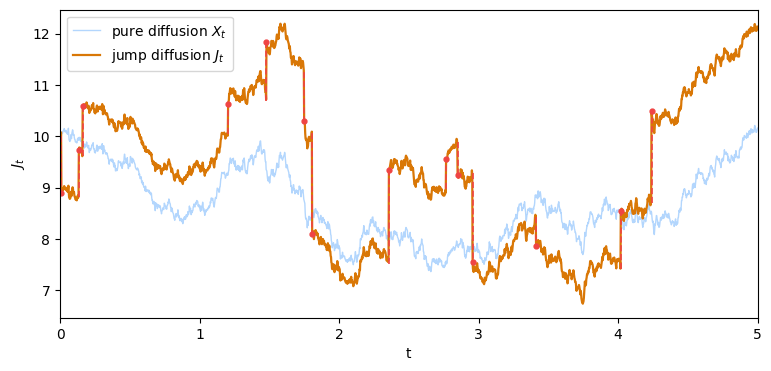

In [7]:
sim = JF.simulate(T=5.0, n=2000, rng=np.random.default_rng(1))
print("number of jumps:", sim.n_jumps)
sim.combined_plot()

The blue curve is the same model without jumps. Any difference between the two curves comes from the jumps.

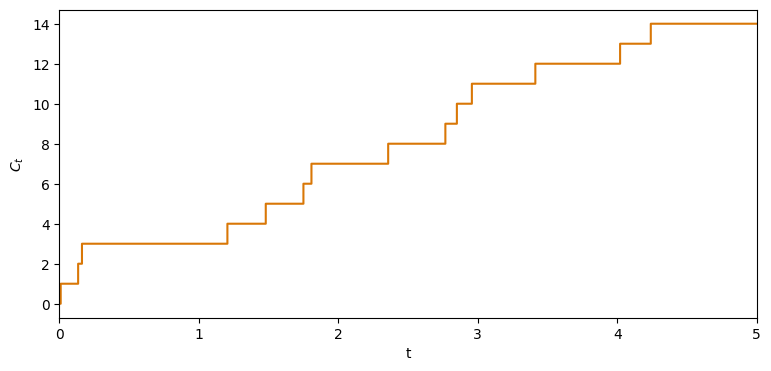

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.step(sim.t, sim.C, where="post", color="#d97706")
ax.set_xlabel("t")
ax.set_ylabel("$C_t$")
ax.margins(x=0)

The simulation result also reports simple jump statistics: first and last jump (time and size), and the largest, smallest and average jump size, optionally restricted to a time window.

In [ ]:
t_first, y_first = sim.first_jump()
t_last, y_last = sim.last_jump()
print(f"first jump:               t = {t_first:.3f}, size = {y_first:+.3f}")
print(f"last jump:                t = {t_last:.3f}, size = {y_last:+.3f}")
print(f"largest jump:             {sim.largest_jump():+.3f}")
print(f"smallest jump:            {sim.smallest_jump():+.3f}")
print(f"average jump size:        {sim.average_jump():.3f}")
print(f"largest jump in [0, 2.5]: {sim.largest_jump(t_min=0.0, t_max=2.5):+.3f}")

We can perform Monte Carlo simulation with jump diffusions by simulating many paths and averaging over them. As an example, we estimate $\mathbb{E}[J_T]$. First, we calculate an analytical reference value. Since $\rho(J_{t^-}, Y_{C_t}) = J_{t^-}+ Y_{C_t}$, we have
\begin{align*}
\mathrm{d}J_t &= \mu(J_t) \, \mathrm{d}t + \, \sigma(J_t) \mathrm{d}W_t + \big(\rho(J_{t^-}, Y_{C_t}) - J_{t^-}\big)\, \mathrm{d}C_t \\
&= 0.3 \, \mathrm{d}t + \, \mathrm{d}W_t + Y_{C_t} \, \mathrm{d}C_t
\end{align*}
and in integral notation

\begin{align*}
J_T
&= x_0 + \int_0^T \mu\, \mathrm{d}t + \int_0^T \sigma \,\mathrm{d}W_t + \sum_{k=1}^{C_T} Y_k \\
&= x_0 + \mu T + \sigma W_T + \sum_{k=1}^{C_T} Y_k.
\end{align*}
It holds $\mathbb{E}[W_T] = 0$ and, by Wald's identity, $\mathbb{E}\big[\sum_{k=1}^{C_T} Y_k\big] = \mathbb{E}[C_T]\, \mathbb{E}[Y] = hT\, \mathbb{E}[Y]$, so
\begin{align*}
\mathbb{E}[J_T]
&= x_0 + \mu T + h\,\mathbb{E}[Y]\, T \\
&= x_0 + \mu T,
\end{align*}
since $Y$ is symmetric, $\mathbb{E}[Y] = 0$. We now set $x_0 = 10$, $\mu = 0.3$ and $T = 1$, then we get $\mathbb{E}[J_T] = 10.3$.

In [9]:
closed_form = 10.3

To generate sample paths we use `simulate_many`.

In [10]:
paths = JF.simulate_many(T=1, n=500, n_paths=50000, rng=np.random.default_rng(5))

simulating:   0%|          | 0/50000 [00:00<?, ? path/s]

We plot the first 30 sample paths.

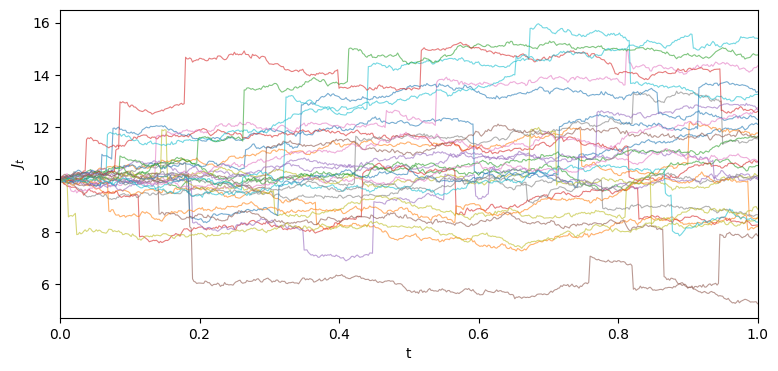

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
for p in paths[:30]:
    ax.plot(p.t, p.J, lw=0.8, alpha=0.6)
ax.set_xlabel("t"); ax.set_ylabel("$J_t$"); ax.margins(x=0);

To estimate $\mathbb{E}[J_T]$ we call `monte_carlo` on the paths. It averages $f(J_t)$ over the paths (default: $f(x) = x$ evaluated at the end time) and returns the estimate together with its standard error.

In [ ]:
est, se = JF.monte_carlo(paths)
print(f"Monte Carlo estimate: {est:.3f} +/- {se:.3f}")
print(f"closed form:          {closed_form:.3f}")

We can plot the resulting distribution.

In [ ]:
J_T = np.array([p.J[-1] for p in paths])
plt.hist(J_T, bins=40, color="#93c5fd")
plt.axvline(closed_form, color="#ff2600", ls="--", label="closed form $\\mathbb{E}[J_T]$")
plt.axvline(J_T.mean(), color="#0519EF", ls="--", label="MC mean", lw=1)
plt.xlabel("$J_T$"); plt.ylabel("count"); plt.legend();

## References

[1] Borodin, A. N. (2017). *Stochastic Processes*. Probability and Its Applications. Birkhäuser/Springer International Publishing, Cham. [https://doi.org/10.1007/978-3-319-62310-8](https://doi.org/10.1007/978-3-319-62310-8) (Chapter VI)